In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [11]:
def analyze_dataset(data_path):
    splits = ['train', 'valid', 'test']
    data_stats = []
    class_counts = {}

    for split in splits:
        img_dir = os.path.join(data_path, split, 'images')
        label_dir = os.path.join(data_path, split, 'labels')

        if not os.path.exists(img_dir):
            print(f"Cảnh báo: Không tìm thấy thư mục {img_dir}")
            continue

        images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        labels = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

        for label_file in labels:
            with open(os.path.join(label_dir, label_file), 'r') as f:
                for line in f:
                    data = line.strip().split()
                    if data:
                        cls = int(data[0])
                        class_counts[cls] = class_counts.get(cls, 0) + 1

        data_stats.append({'Split': split, 'Images': len(images), 'Labels': len(labels)})

    return data_stats, class_counts

In [12]:
stats, counts = analyze_dataset('data')

df_stats = pd.DataFrame(stats)
print("--- Thống kê số lượng ảnh và file nhãn ---")
display(df_stats)

--- Thống kê số lượng ảnh và file nhãn ---


,Split,Images,Labels
0,train,892,892
1,valid,143,143
2,test,71,71


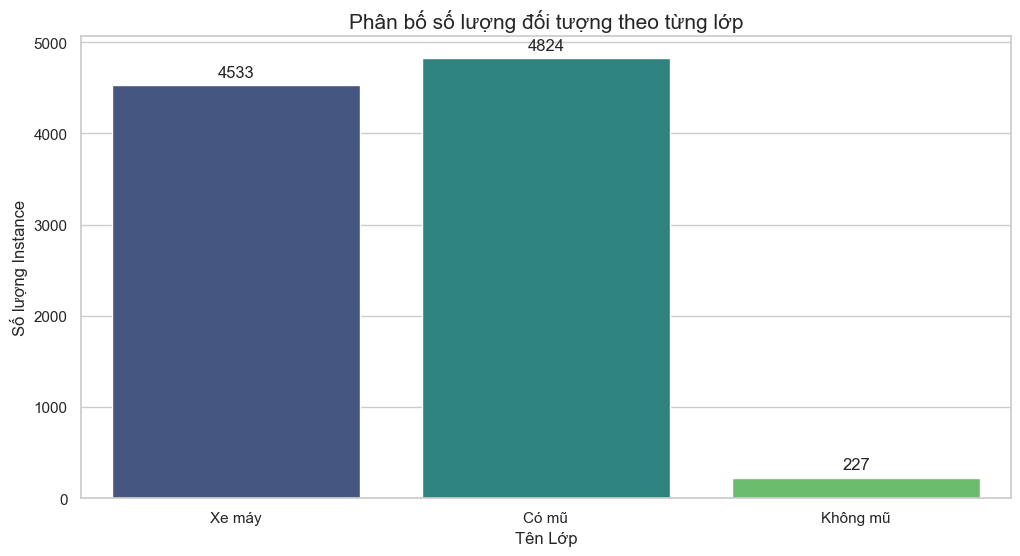

In [13]:
class_names_map = {0: 'Xe máy', 1: 'Có mũ', 2: 'Không mũ'}

sorted_keys = sorted(counts.keys())
names = [class_names_map.get(k, f"Class {k}") for k in sorted_keys]
values = [counts[k] for k in sorted_keys]

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=names, y=values, hue=names, palette='viridis', legend=False)

plt.title('Phân bố số lượng đối tượng theo từng lớp', fontsize=15)
plt.xlabel('Tên Lớp', fontsize=12)
plt.ylabel('Số lượng Instance', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.show()

=== THỐNG KÊ TẬP TRAIN ===
Số lượng ảnh: 892
- Xe máy: 3578 đối tượng
- Có mũ: 3805 đối tượng
- Không mũ: 183 đối tượng


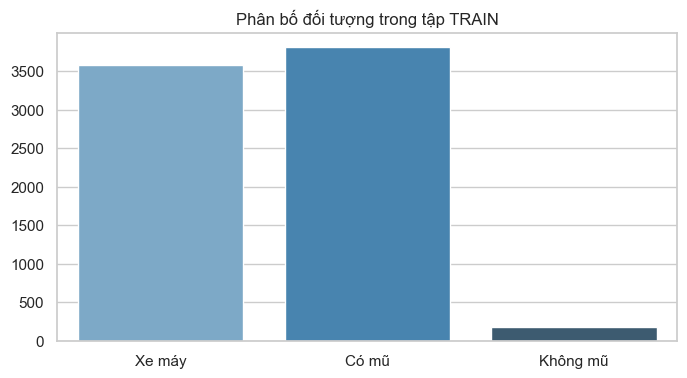

In [14]:
split = 'train'
img_dir = os.path.join('data', split, 'images')
label_dir = os.path.join('data', split, 'labels')

train_counts = {0: 0, 1: 0, 2: 0}
for label_file in [f for f in os.listdir(label_dir) if f.endswith('.txt')]:
    with open(os.path.join(label_dir, label_file), 'r') as f:
        for line in f:
            data = line.strip().split()
            if data:
                cls = int(data[0])
                train_counts[cls] = train_counts.get(cls, 0) + 1
print(f"=== THỐNG KÊ TẬP {split.upper()} ===")
print(f"Số lượng ảnh: {len(os.listdir(img_dir))}")
for k, v in train_counts.items():
    name = class_names_map.get(k)
    print(f"- {name}: {v} đối tượng")

plt.figure(figsize=(8, 4))
names = ['Xe máy', 'Có mũ', 'Không mũ']
values = [train_counts[0], train_counts[1], train_counts[2]]

sns.barplot(x=names, y=values, hue=names, palette='Blues_d', legend=False)
plt.title(f'Phân bố đối tượng trong tập {split.upper()}')
plt.show()

=== THỐNG KÊ TẬP VALID ===
Số lượng ảnh: 143
- Xe máy: 623 đối tượng
- Có mũ: 675 đối tượng
- Không mũ: 27 đối tượng


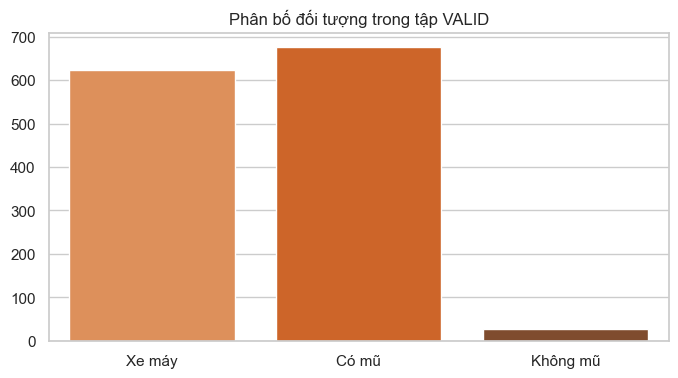

In [15]:
split = 'valid'
img_dir = os.path.join('data', split, 'images')
label_dir = os.path.join('data', split, 'labels')

valid_counts = {0: 0, 1: 0, 2: 0}
for label_file in [f for f in os.listdir(label_dir) if f.endswith('.txt')]:
    with open(os.path.join(label_dir, label_file), 'r') as f:
        for line in f:
            data = line.strip().split()
            if data:
                cls = int(data[0])
                valid_counts[cls] = valid_counts.get(cls, 0) + 1

print(f"=== THỐNG KÊ TẬP {split.upper()} ===")
print(f"Số lượng ảnh: {len(os.listdir(img_dir))}")
for k, v in valid_counts.items():
    name = class_names_map.get(k)
    print(f"- {name}: {v} đối tượng")

plt.figure(figsize=(8, 4))
names = ['Xe máy', 'Có mũ', 'Không mũ']
values = [valid_counts[0], valid_counts[1], valid_counts[2]]

sns.barplot(x=names, y=values, hue=names, palette='Oranges_d', legend=False)
plt.title(f'Phân bố đối tượng trong tập {split.upper()}')
plt.show()

=== THỐNG KÊ TẬP TEST ===
Số lượng ảnh: 71
- Xe máy: 332 đối tượng
- Có mũ: 344 đối tượng
- Không mũ: 17 đối tượng


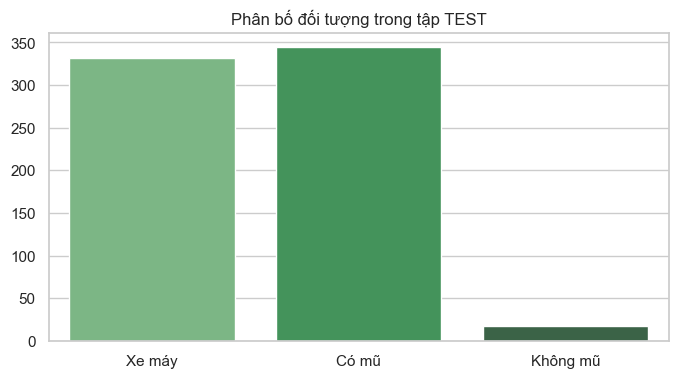

In [16]:
split = 'test'
img_dir = os.path.join('data', split, 'images')
label_dir = os.path.join('data', split, 'labels')

test_counts = {0: 0, 1: 0, 2: 0}
for label_file in [f for f in os.listdir(label_dir) if f.endswith('.txt')]:
    with open(os.path.join(label_dir, label_file), 'r') as f:
        for line in f:
            data = line.strip().split()
            if data:
                cls = int(data[0])
                test_counts[cls] = test_counts.get(cls, 0) + 1

print(f"=== THỐNG KÊ TẬP {split.upper()} ===")
print(f"Số lượng ảnh: {len(os.listdir(img_dir))}")
for k, v in test_counts.items():
    name = class_names_map.get(k)
    print(f"- {name}: {v} đối tượng")

plt.figure(figsize=(8, 4))
names = ['Xe máy', 'Có mũ', 'Không mũ']
values = [test_counts[0], test_counts[1], test_counts[2]]

sns.barplot(x=names, y=values, hue=names, palette='Greens_d', legend=False)
plt.title(f'Phân bố đối tượng trong tập {split.upper()}')
plt.show()